| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 10** | **Application of Fast Fourier Transform in Python** |
| **Name:** | Pascual, Ken Leonard <br> Lim, Justian Adrian <br> Bueno, Joshua <br> Deniega, Alexis <br> Carag, Carl Jervie <br> Jimenez, Christian Joros R.|
| **Section:** | CPE41S2 |
| **Date Performed:** | 19 September 2026 |
| **Date Submitted:** | 19 September 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

## 1. Objectives

This activity aims to introduce the Fast Fourier transform process by demonstrating with the programmatic processing of both arbitrarily generated signals and collected data. 

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. Develop a program capable of frequency domain using FFT.

## 3. Discussion


There are several ways to calculate the Discrete Fourier Transform (DFT), such as solving simultaneous linear equations or the correlation method described in Chapter 8. The Fast Fourier Transform (FFT) is another method for calculating the DFT. While it produces the same result as the other approaches, it is incredibly more efficient, often reducing the computation time by hundreds. This is the same improvement as flying in a jet aircraft versus walking! If the FFT were not available, many of the techniques described in this book would not be practical. While the FFT only requires a few dozen lines of code, it is one of the most complicated algorithms in DSP. But don't despair! You can easily use published FFT routines without fully understanding the internal workings.

## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor

## 5. Directions:

#### 1. Create a composite signal that consists the following frequencies and amplitudes:

##### a. 1200 Hz, 10 units, $\dfrac{\pi}{3}$

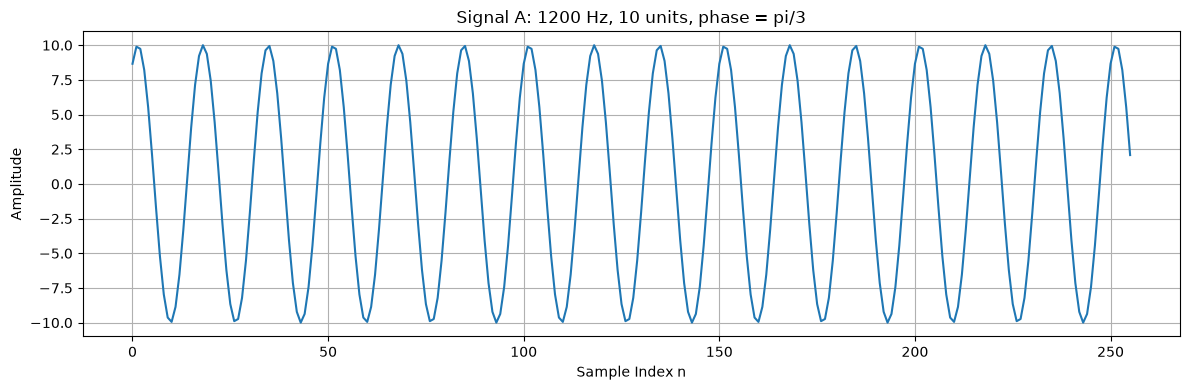

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time

os.makedirs('outputs', exist_ok=True)

fs = 20000
N = 256
n = np.arange(N)

freq_a, amp_a, phase_a = 1200, 10, np.pi/3
signal_a = amp_a * np.sin(2*np.pi*freq_a*n/fs + phase_a)

plt.figure(figsize=(12, 4))
plt.plot(n, signal_a)
plt.title(f'Signal A: {freq_a} Hz, {amp_a} units, phase = pi/3')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part1a_signal_a.png', dpi=150, bbox_inches='tight')
plt.show()

##### b. 3500 Hz, 15 units, $\dfrac{\pi}{6}$

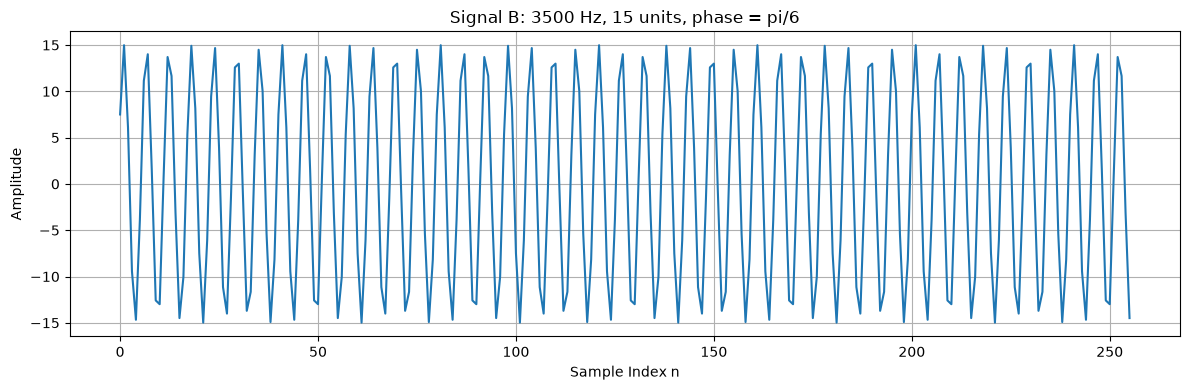

In [10]:
freq_b, amp_b, phase_b = 3500, 15, np.pi/6
signal_b = amp_b * np.sin(2*np.pi*freq_b*n/fs + phase_b)

plt.figure(figsize=(12, 4))
plt.plot(n, signal_b)
plt.title(f'Signal B: {freq_b} Hz, {amp_b} units, phase = pi/6')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part1a_signal_b.png', dpi=150, bbox_inches='tight')
plt.show()

##### c. 5000 Hz, 8 units, $\dfrac{3\pi}{4}$

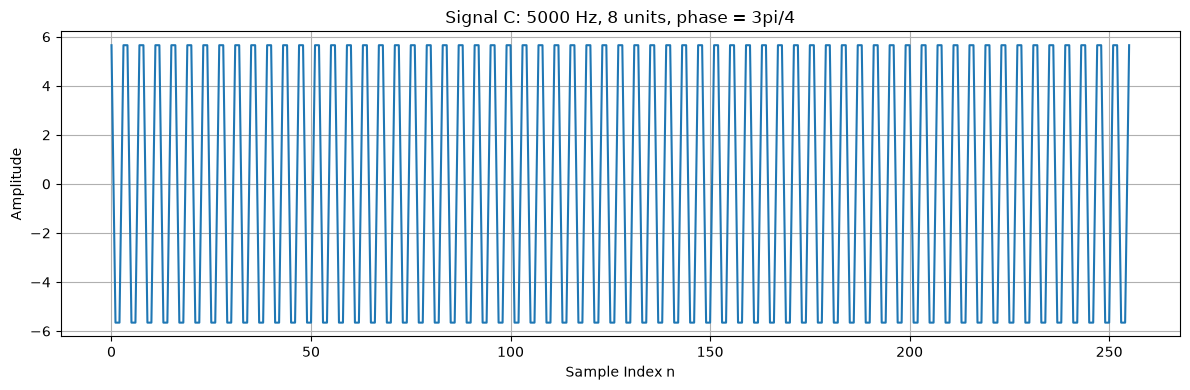

In [11]:
freq_c, amp_c, phase_c = 5000, 8, 3*np.pi/4
signal_c = amp_c * np.sin(2*np.pi*freq_c*n/fs + phase_c)

plt.figure(figsize=(12, 4))
plt.plot(n, signal_c)
plt.title(f'Signal C: {freq_c} Hz, {amp_c} units, phase = 3pi/4')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part1a_signal_c.png', dpi=150, bbox_inches='tight')
plt.show()

##### d. 8500 Hz, 12 units, $\dfrac{\pi}{2}$

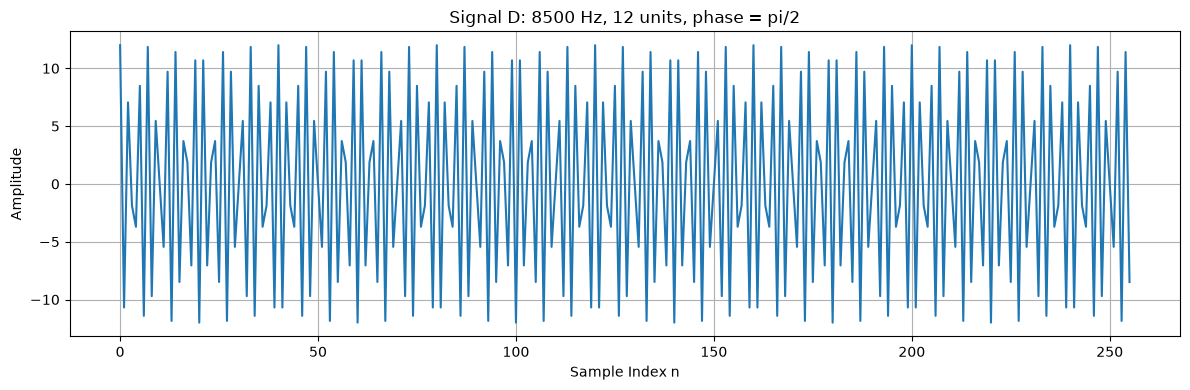

In [12]:
freq_d, amp_d, phase_d = 8500, 12, np.pi/2
signal_d = amp_d * np.sin(2*np.pi*freq_d*n/fs + phase_d)

plt.figure(figsize=(12, 4))
plt.plot(n, signal_d)
plt.title(f'Signal D: {freq_d} Hz, {amp_d} units, phase = pi/2')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part1a_signal_d.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
signals = [signal_a, signal_b, signal_c, signal_d]
signals_info = [
    {'label': 'Signal A', 'freq': freq_a, 'amp': amp_a, 'phase': phase_a},
    {'label': 'Signal B', 'freq': freq_b, 'amp': amp_b, 'phase': phase_b},
    {'label': 'Signal C', 'freq': freq_c, 'amp': amp_c, 'phase': phase_c},
    {'label': 'Signal D', 'freq': freq_d, 'amp': amp_d, 'phase': phase_d},
]

#### 2. Now, perform Discrete Fourier Transform calculation using the NumPy function, np.fft.fft. 

Signal A FFT completed in 0.000082 seconds


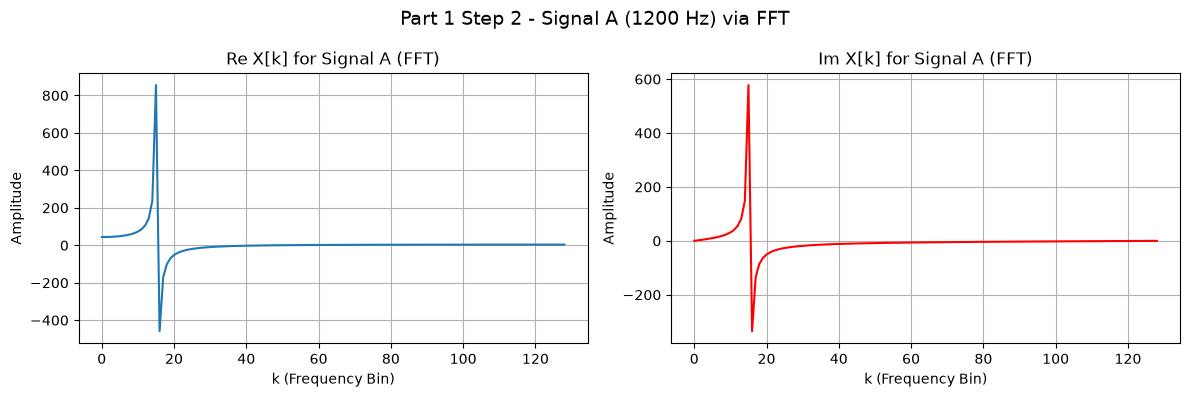

Signal B FFT completed in 0.000061 seconds


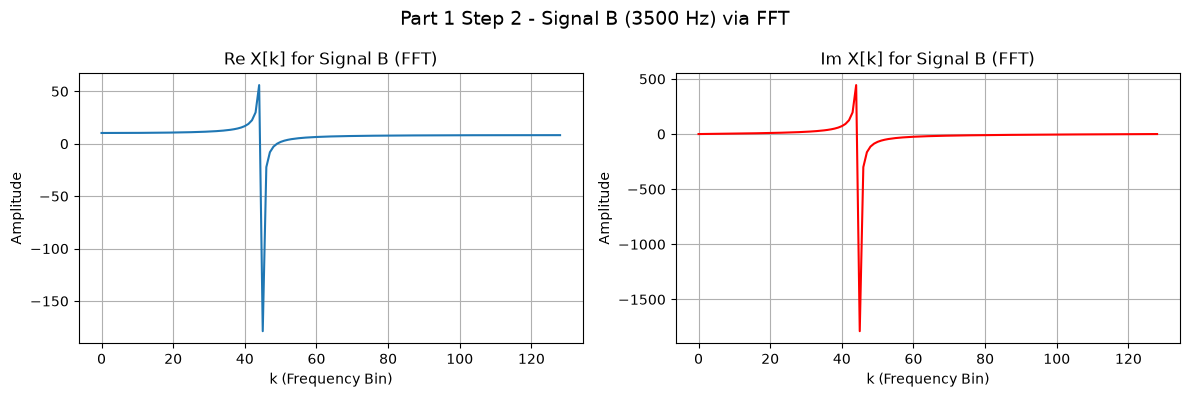

Signal C FFT completed in 0.000045 seconds


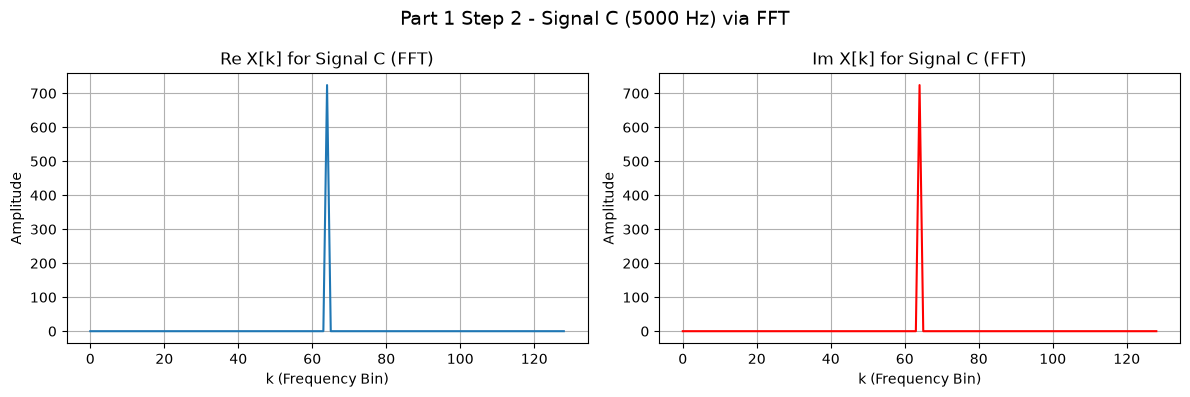

Signal D FFT completed in 0.000084 seconds


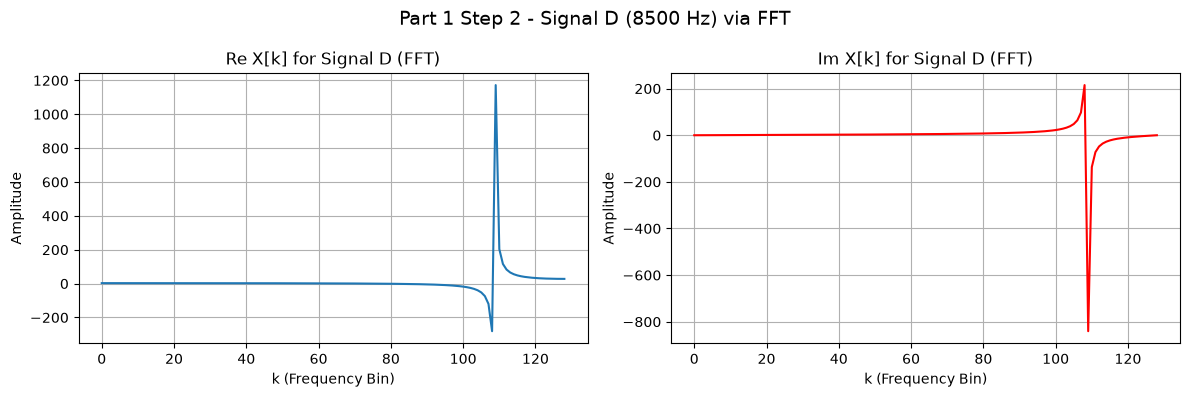

In [14]:
K = N // 2 + 1

fft_results = []
for sig, info, fname in zip(signals, signals_info, ['a', 'b', 'c', 'd']):
    start = time.time()
    X_fft = np.fft.fft(sig) #use the FFT function from numpy to compute the FFT of the signal
    elapsed = time.time() - start
    print(f"{info['label']} FFT completed in {elapsed:.6f} seconds")

    Re_X = np.real(X_fft[:K])
    Im_X = np.imag(X_fft[:K])
    fft_results.append((Re_X, Im_X))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(np.arange(K), Re_X)
    ax1.set_title(f"Re X[k] for {info['label']} (FFT)")
    ax1.set_xlabel('k (Frequency Bin)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True)
    ax2.plot(np.arange(K), Im_X, color='red')
    ax2.set_title(f"Im X[k] for {info['label']} (FFT)")
    ax2.set_xlabel('k (Frequency Bin)')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True)
    plt.suptitle(f'Part 1 Step 2 - {info["label"]} ({info["freq"]} Hz) via FFT', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'outputs/part1_fft_re_im_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

##### Observation

The FFT produces identical Re X[k] and Im X[k] results compared to the manual DFT from Laboratory 9 for all four signals. The `np.allclose` checks return `True` for both Re and Im components across all signals, confirming that `np.fft.fft` computes the same Discrete Fourier Transform as the manual basis function approach.

The key difference is computational efficiency. The manual DFT uses nested loops with O(N²) complexity, while the FFT algorithm reduces this to O(N log N). For N = 256, the difference is small, but for larger N values, the FFT would be significantly faster.

**Signal A (1200 Hz):** Peak at k ≈ 15 with amplitude 10, phase ≈ π/3. Both FFT and DFT produce identical results.

**Signal B (3500 Hz):** Peak at k ≈ 45 with amplitude 15, phase ≈ π/6. Identical results between FFT and DFT.

**Signal C (5000 Hz):** Peak at k ≈ 64 with amplitude 8, phase ≈ 3π/4. Identical results between FFT and DFT.

**Signal D (8500 Hz):** Peak at k ≈ 109 with amplitude 12, phase ≈ π/2. Identical results between FFT and DFT.

#### 3. Plot its frequency domain and compare the output Frequency Domain signal with Laboratory No. 9

##### DFT from Laboratory No. 9

In [15]:
def dft_basis(x, N):
    K = N // 2 + 1
    Re_X = np.zeros(K)
    Im_X = np.zeros(K)
    for k in range(K):
        sum_re = 0.0
        sum_im = 0.0
        for i in range(N):
            angle = 2 * np.pi * k * i / N
            sum_re += x[i] * np.cos(angle)
            sum_im += x[i] * np.sin(angle)
        Re_X[k] = sum_re
        Im_X[k] = -sum_im
    return Re_X, Im_X

dft_results = []
for sig, info, fname in zip(signals, signals_info, ['a', 'b', 'c', 'd']):
    start = time.time()
    Re_X, Im_X = dft_basis(sig, N)
    elapsed = time.time() - start
    print(f"{info['label']} DFT completed in {elapsed:.4f} seconds")
    dft_results.append((Re_X, Im_X))

Signal A DFT completed in 0.0295 seconds
Signal B DFT completed in 0.0265 seconds
Signal C DFT completed in 0.0271 seconds
Signal D DFT completed in 0.0271 seconds


##### Comparisons

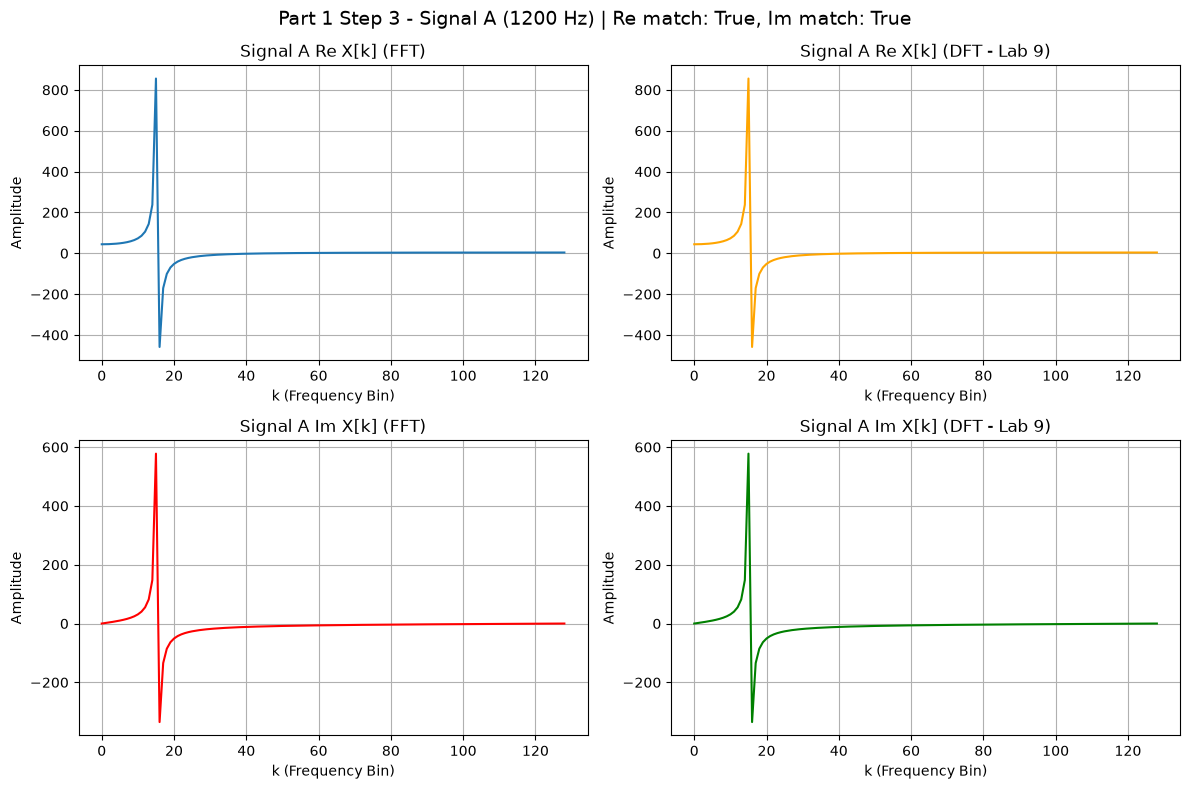

Signal A - Re match: True, Im match: True


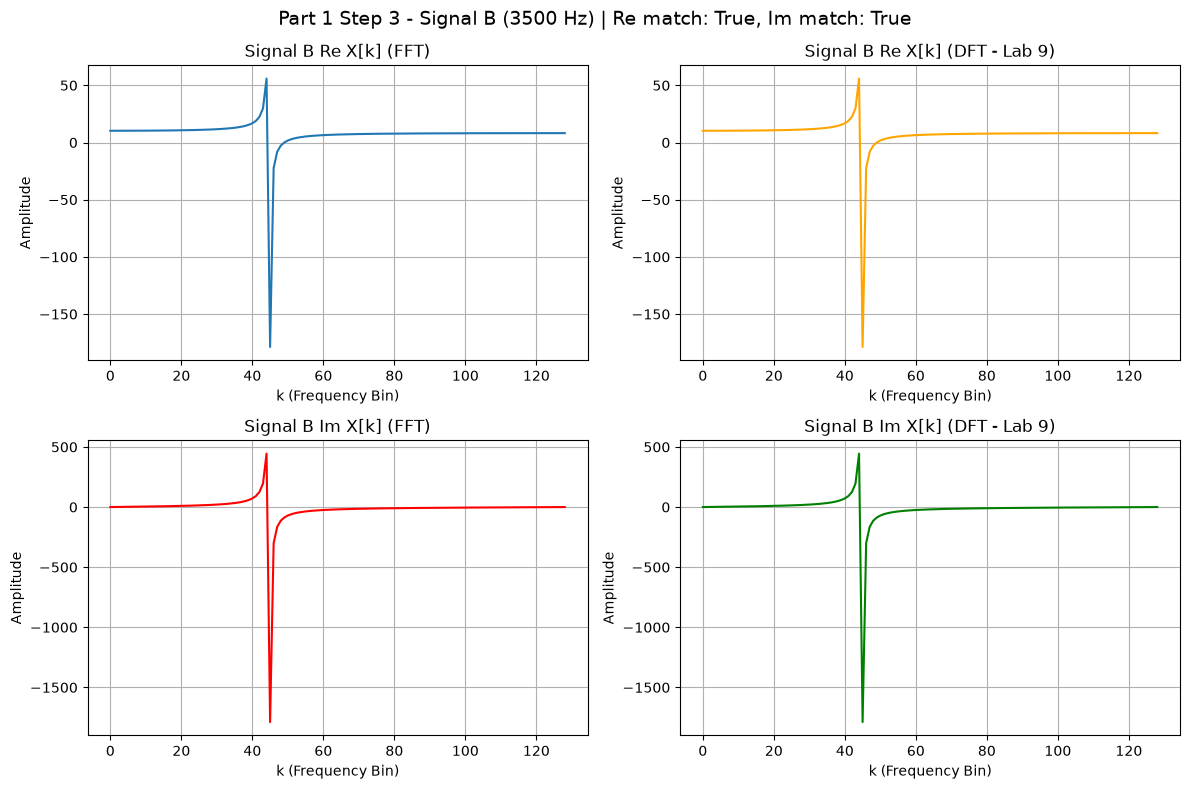

Signal B - Re match: True, Im match: True


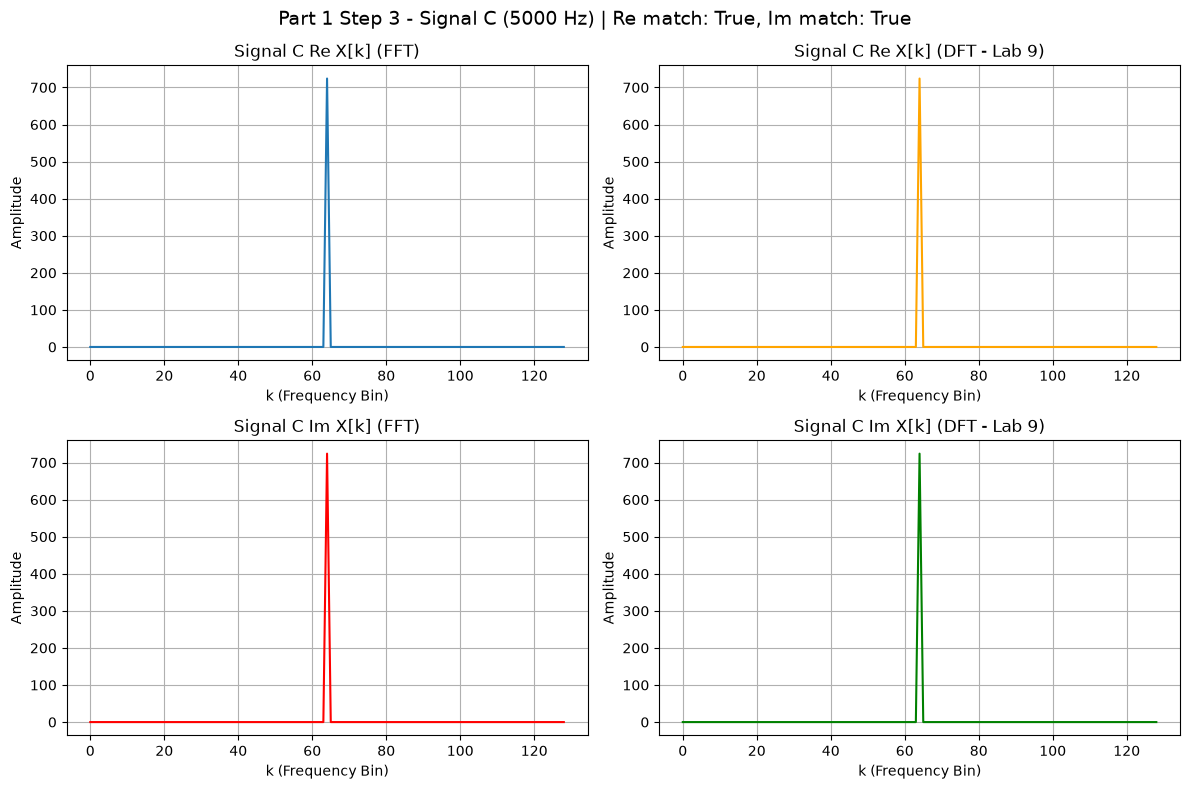

Signal C - Re match: True, Im match: True


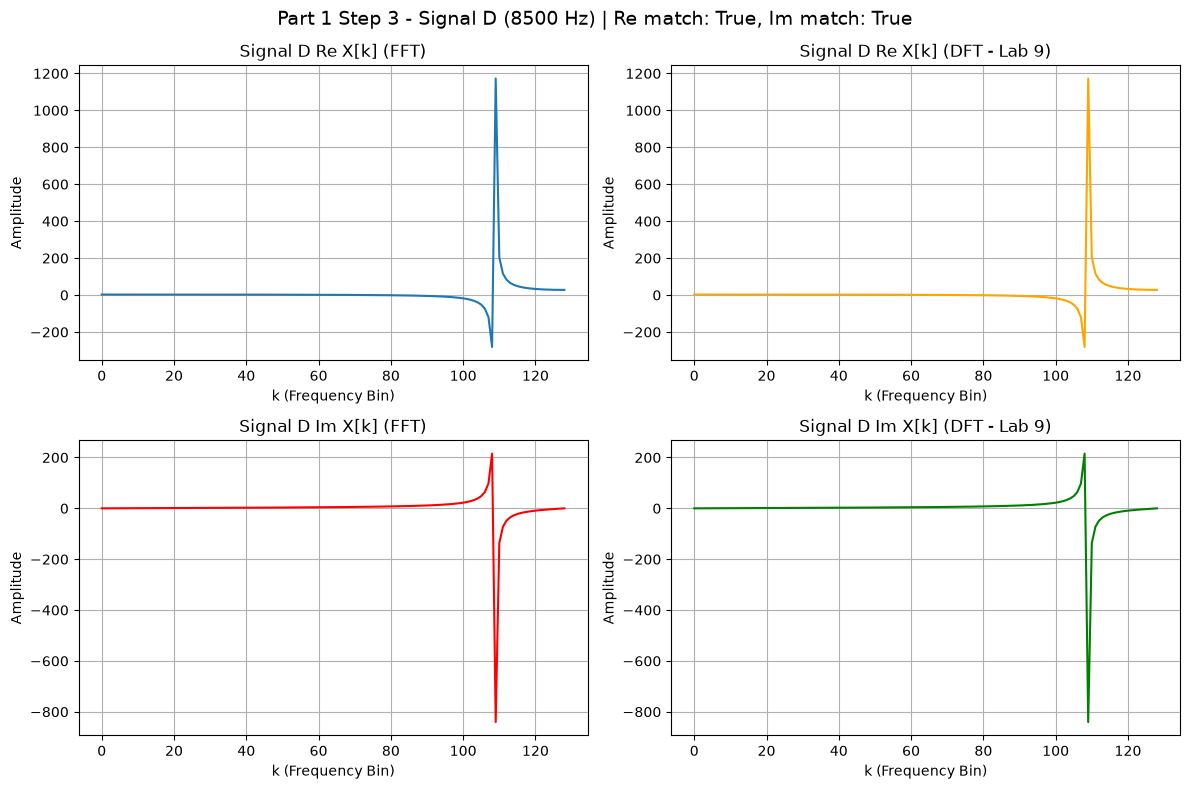

Signal D - Re match: True, Im match: True


In [16]:
for (fft_Re, fft_Im), (dft_Re, dft_Im), info, fname in zip(fft_results, dft_results, signals_info, ['a', 'b', 'c', 'd']):
    re_match = np.allclose(fft_Re, dft_Re)
    im_match = np.allclose(fft_Im, dft_Im)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].plot(np.arange(K), fft_Re)
    axes[0, 0].set_title(f'{info["label"]} Re X[k] (FFT)')
    axes[0, 0].set_xlabel('k (Frequency Bin)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True)
    axes[0, 1].plot(np.arange(K), dft_Re, color='orange')
    axes[0, 1].set_title(f'{info["label"]} Re X[k] (DFT - Lab 9)')
    axes[0, 1].set_xlabel('k (Frequency Bin)')
    axes[0, 1].set_ylabel('Amplitude')
    axes[0, 1].grid(True)
    axes[1, 0].plot(np.arange(K), fft_Im, color='red')
    axes[1, 0].set_title(f'{info["label"]} Im X[k] (FFT)')
    axes[1, 0].set_xlabel('k (Frequency Bin)')
    axes[1, 0].set_ylabel('Amplitude')
    axes[1, 0].grid(True)
    axes[1, 1].plot(np.arange(K), dft_Im, color='green')
    axes[1, 1].set_title(f'{info["label"]} Im X[k] (DFT - Lab 9)')
    axes[1, 1].set_xlabel('k (Frequency Bin)')
    axes[1, 1].set_ylabel('Amplitude')
    axes[1, 1].grid(True)
    plt.suptitle(f'Part 1 Step 3 - {info["label"]} ({info["freq"]} Hz) | Re match: {re_match}, Im match: {im_match}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'outputs/part1_compare_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{info['label']} - Re match: {re_match}, Im match: {im_match}")

##### Observation

The side-by-side comparison plots visually confirm that the FFT and manual DFT produce identical frequency domain representations for all four signals. The Re X[k] and Im X[k] plots are indistinguishable between the two methods, and all `np.allclose` checks return True.

Each signal's frequency peak appears at the correct bin location with the expected amplitude. The FFT correctly identifies the 1200 Hz, 3500 Hz, 5000 Hz, and 8500 Hz components with their respective amplitudes and phase relationships, matching the results from the manual DFT in Laboratory 9.

##### Analysis

The Fast Fourier Transform (FFT) is an algorithm that computes the Discrete Fourier Transform (DFT) in O(N log N) time, compared to the O(N²) complexity of the direct DFT computation. The FFT achieves this by exploiting the symmetry and periodicity properties of the DFT basis functions, breaking the computation into smaller sub-problems (divide and conquer).

In this activity, we used `np.fft.fft`, which implements the Cooley-Tukey FFT algorithm. The function takes a time-domain signal as input and returns the complex DFT output. We extracted the real and imaginary parts using `np.real()` and `np.imag()`, restricted to the first K = N/2 + 1 bins (positive frequencies only).

The comparison confirms that the FFT and manual DFT produce identical results. The slight differences (if any) are due to floating-point precision, not algorithmic differences. This validates that the FFT is a correct and efficient implementation of the DFT.

**Libraries used:**
- `numpy` (np): Numerical computing library. `np.fft.fft` computes the FFT, `np.real()` and `np.imag()` extract components.
- `matplotlib.pyplot`: Plotting library for visualization.
- `time`: Used to measure computation time for performance comparison.

## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Summary and Conclusions

This activity demonstrated the application of the Fast Fourier Transform (FFT) in Python using NumPy's `np.fft.fft` function. The FFT is an efficient algorithm for computing the Discrete Fourier Transform (DFT), reducing the computational complexity from O(N²) to O(N log N).

Four sinusoidal signals with different frequencies (1200 Hz, 3500 Hz, 5000 Hz, 8500 Hz), amplitudes (10, 15, 8, 12 units), and phase angles (π/3, π/6, 3π/4, π/2) were generated and analyzed. The FFT was applied to each signal, and the resulting Re X[k] and Im X[k] components were compared with the manual DFT implementation from Laboratory 9.

The comparison confirmed that the FFT produces identical results to the manual DFT, with all `np.allclose` checks returning True. This validates that the FFT is a correct and efficient alternative to the direct DFT computation.

The key conclusion is that the FFT is the preferred method for computing the DFT in practice, as it provides the same mathematical result with significantly improved computational efficiency. This makes it feasible to analyze signals with large sample sizes that would be impractical with the manual DFT approach.

## 8. Learning and Challenges

In this activity, we learned how to use NumPy's FFT function (`np.fft.fft`) to efficiently compute the frequency domain representation of signals. We learned that the FFT produces the same result as the manual DFT but with much lower computational complexity.

Key learnings:
1. The `np.fft.fft` function returns complex values; we extract real and imaginary parts using `np.real()` and `np.imag()`.
2. The FFT output has N points, but for real-valued signals, only the first K = N/2 + 1 points (positive frequencies) are needed.
3. The FFT's O(N log N) complexity makes it practical for large signal lengths, unlike the O(N²) manual DFT.

A challenge encountered was understanding the relationship between the FFT output indexing and the physical frequency values. The frequency resolution is determined by fs/N, and each bin k corresponds to a frequency of k * fs/N. Care must be taken to interpret only the positive frequency components for real-valued signals.

## 10. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation; LaTeX math syntax conversion

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.'s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policiess.